# Trust Attribution Analysis

This notebook analyses behavioural data from the **Humanlike AI Systems and Trust Attribution** experiment.

**Conditions:**
- **Condition A (System 7):** Neutral system icon, grey palette, formal tone, calibrated confidence
- **Condition B (Alex):** Human initials avatar, warm blue palette, conversational tone, overstated confidence

**Key metrics:**
1. Reliance rate by condition
2. Override rate by condition
3. Mean response latency by condition

In [1]:
%pip install --upgrade numpy pandas scipy scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': '#fafafa',
    'axes.facecolor': '#fafafa',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {'A': '#6b7280', 'B': '#2563eb'}
LABELS = {'A': 'System 7 (Neutral)', 'B': 'Alex (Humanlike)'}

## 1 · Load data

In [ ]:

with open('sample_output.json') as f:
    events = json.load(f)

df = pd.DataFrame(events)
print(f'Loaded {len(df)} events from {df["participant_id"].nunique()} participants')
df.head()

Loaded 48 events from 8 participants


,event_id,participant_id,session_id,condition,task_id,decision,timestamp,latency_ms,confidence_rating,agent_name,tone,confidence_framing,task_domain,task_stakes
0,03b2108f-940b-469b-941c-a28ede8a666f,p001,fccf7d7c-731,A,t5,accept,2026-03-15T09:00:41.000000+00:00Z,3642,8,System 7,formal,calibrated,consumer,low
1,c060cc9a-721c-4dba-a762-d4dbc6e412b3,p001,fccf7d7c-731,A,t1,override,2026-03-15T09:01:23.000000+00:00Z,5216,6,System 7,formal,calibrated,medical,high
2,47149b11-8119-4a73-becb-6973b0983d4d,p001,fccf7d7c-731,A,t3,override,2026-03-15T09:03:05.000000+00:00Z,3855,6,System 7,formal,calibrated,hiring,high
3,f1603096-677a-4063-a624-f6de7bd3cf92,p001,fccf7d7c-731,B,t2,accept,2026-03-15T09:06:00.000000+00:00Z,2852,7,Alex,conversational,overstated,finance,high
4,b745f9d1-43eb-4814-93e1-535e050fd24f,p001,fccf7d7c-731,B,t6,accept,2026-03-15T09:06:54.000000+00:00Z,1845,6,Alex,conversational,overstated,everyday,low


## 2 · Reliance rate by condition

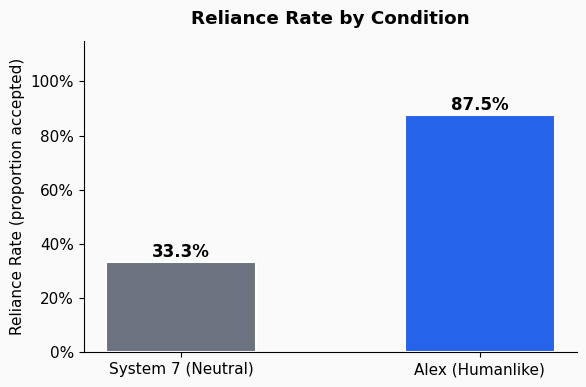

In [4]:
reliance = df.groupby('condition')['decision'].apply(
    lambda x: (x == 'accept').mean()
).rename('reliance_rate')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    [LABELS.get(c, c) for c in reliance.index],
    reliance.values,
    color=[COLORS.get(c, '#999') for c in reliance.index],
    width=0.5,
    edgecolor='white',
    linewidth=1.5,
)
for bar, val in zip(bars, reliance.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.1%}', ha='center', fontweight='bold', fontsize=12)

ax.set_ylabel('Reliance Rate (proportion accepted)')
ax.set_title('Reliance Rate by Condition', fontweight='bold', pad=12)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('reliance_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · Override rate by condition

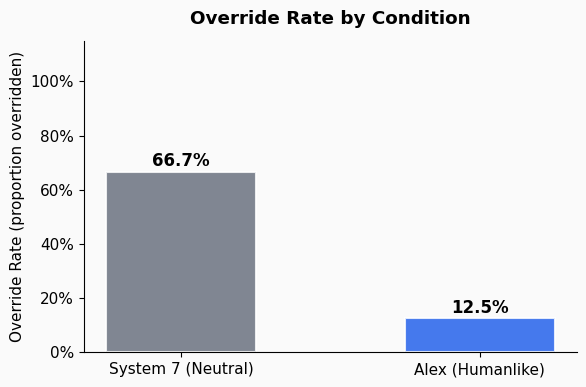

In [5]:
override = df.groupby('condition')['decision'].apply(
    lambda x: (x == 'override').mean()
).rename('override_rate')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    [LABELS.get(c, c) for c in override.index],
    override.values,
    color=[COLORS.get(c, '#999') for c in override.index],
    width=0.5,
    edgecolor='white',
    linewidth=1.5,
    alpha=0.85,
)
for bar, val in zip(bars, override.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.1%}', ha='center', fontweight='bold', fontsize=12)

ax.set_ylabel('Override Rate (proportion overridden)')
ax.set_title('Override Rate by Condition', fontweight='bold', pad=12)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('override_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Mean response latency by condition

C:\Users\Preethi.R\AppData\Local\Temp\ipykernel_17328\310904635.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


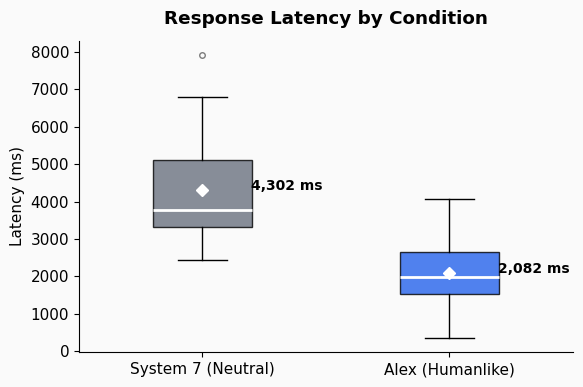

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

conditions = sorted(df['condition'].unique())
data_by_cond = [df[df['condition'] == c]['latency_ms'] for c in conditions]

bp = ax.boxplot(
    data_by_cond,
    labels=[LABELS.get(c, c) for c in conditions],
    patch_artist=True,
    widths=0.4,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
)
for patch, c in zip(bp['boxes'], conditions):
    patch.set_facecolor(COLORS.get(c, '#999'))
    patch.set_alpha(0.8)

for i, c in enumerate(conditions):
    mean_val = data_by_cond[i].mean()
    ax.plot(i + 1, mean_val, 'D', color='white', markersize=6, zorder=5)
    ax.annotate(f'{mean_val:,.0f} ms', (i + 1, mean_val),
                textcoords='offset points', xytext=(35, 0),
                fontsize=10, fontweight='bold')

ax.set_ylabel('Latency (ms)')
ax.set_title('Response Latency by Condition', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('latency_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Statistical tests

In [7]:
# Chi-square test: is the reliance rate significantly different between conditions?
ct = pd.crosstab(df['condition'], df['decision'])
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print('=== Chi-square test (reliance vs condition) ===')
print(f'  χ² = {chi2:.4f},  p = {p_chi:.4f},  df = {dof}')
print(f'  Significant at α=0.05? {"Yes" if p_chi < 0.05 else "No"}\n')

# Independent-samples t-test on latency
lat_a = df[df['condition'] == 'A']['latency_ms']
lat_b = df[df['condition'] == 'B']['latency_ms']
t_stat, p_t = stats.ttest_ind(lat_a, lat_b, equal_var=False)
print('=== Welch t-test (latency) ===')
print(f'  t = {t_stat:.4f},  p = {p_t:.4f}')
print(f'  Mean A = {lat_a.mean():.0f} ms,  Mean B = {lat_b.mean():.0f} ms')
print(f'  Significant at α=0.05? {"Yes" if p_t < 0.05 else "No"}')

=== Chi-square test (reliance vs condition) ===
  χ² = 12.5445,  p = 0.0004,  df = 1
  Significant at α=0.05? Yes

=== Welch t-test (latency) ===
  t = 6.5760,  p = 0.0000
  Mean A = 4302 ms,  Mean B = 2082 ms
  Significant at α=0.05? Yes


## 6 · Summary table

In [8]:
summary = df.groupby('condition').agg(
    n_events=('event_id', 'count'),
    n_participants=('participant_id', 'nunique'),
    accept_count=('decision', lambda x: (x == 'accept').sum()),
    override_count=('decision', lambda x: (x == 'override').sum()),
    reliance_rate=('decision', lambda x: (x == 'accept').mean()),
    mean_latency=('latency_ms', 'mean'),
    median_latency=('latency_ms', 'median'),
)
summary.index = summary.index.map(LABELS)
summary = summary.round(3)
summary

,n_events,n_participants,accept_count,override_count,reliance_rate,mean_latency,median_latency
condition,,,,,,,
System 7 (Neutral),24,8,8,16,0.333,4302.208,3763.0
Alex (Humanlike),24,8,21,3,0.875,2081.708,1990.0


## 7 · Trust scale comparison (if available)

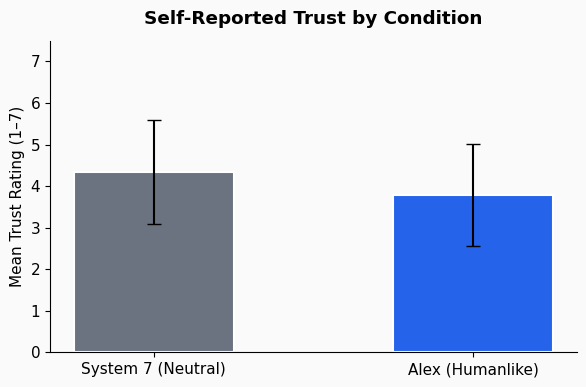

In [9]:
import os

trust_path = '../backend/trust_scale.json'
if os.path.exists(trust_path):
    with open(trust_path) as f:
        trust_data = json.load(f)
    tdf = pd.DataFrame(trust_data)
    tdf['trust_mean'] = tdf[['trust_q1', 'trust_q2', 'trust_q3']].mean(axis=1)

    fig, ax = plt.subplots(figsize=(6, 4))
    for c in sorted(tdf['condition'].unique()):
        subset = tdf[tdf['condition'] == c]
        ax.bar(
            LABELS.get(c, c),
            subset['trust_mean'].mean(),
            yerr=subset['trust_mean'].std(),
            color=COLORS.get(c, '#999'),
            width=0.5,
            edgecolor='white',
            linewidth=1.5,
            capsize=5,
        )

    ax.set_ylabel('Mean Trust Rating (1–7)')
    ax.set_title('Self-Reported Trust by Condition', fontweight='bold', pad=12)
    ax.set_ylim(0, 7.5)
    plt.tight_layout()
    plt.savefig('trust_scale.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No trust_scale.json found — run the experiment first.')